# Week 2 — Clean and Summarise

**What you will do this week:**
1. Find and handle missing values
2. Spot and fix data problems
3. Build a clean summary table
4. Save it as a CSV for Superset

**By the end of this notebook you should have:**
- A clean version of the stock data with no missing values
- A summary table saved to `data/summary.csv` ready to load into Superset

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

stock = pd.read_csv('../data/stock.csv')
print(f'Loaded {len(stock):,} rows')

Loaded 2,149 rows


## 1. Find missing values

Missing values appear as `NaN` in pandas. `.isnull().sum()` tells you how many are in each column.

In [2]:
# Count missing values per column
stock.isnull().sum()

facility_id       0
facility_type     0
zone              0
lead_time_days    0
medicine          0
month             0
stock_on_hand     0
consumption       0
resupply          0
days_of_stock     0
stockout          0
dtype: int64

In [3]:
# What percentage of each column is missing?
(stock.isnull().sum() / len(stock) * 100).round(1)

facility_id       0.0
facility_type     0.0
zone              0.0
lead_time_days    0.0
medicine          0.0
month             0.0
stock_on_hand     0.0
consumption       0.0
resupply          0.0
days_of_stock     0.0
stockout          0.0
dtype: float64

## 2. Handle missing values

For numeric columns, we fill missing values with the **median** of that medicine.
The median is safer than the mean because it is not affected by extreme values.

We use `groupby` + `transform` to fill each missing value with the median
for that specific medicine (rather than the overall median).

In [4]:
# Fill missing days_of_stock with the median for that medicine
stock['days_of_stock'] = stock['days_of_stock'].fillna(
    stock.groupby('medicine')['days_of_stock'].transform('median')
)

# Fill missing consumption the same way
stock['consumption'] = stock['consumption'].fillna(
    stock.groupby('medicine')['consumption'].transform('median')
)

# Check — should now be zero
print('Missing values remaining:')
print(stock.isnull().sum())

Missing values remaining:
facility_id       0
facility_type     0
zone              0
lead_time_days    0
medicine          0
month             0
stock_on_hand     0
consumption       0
resupply          0
days_of_stock     0
stockout          0
dtype: int64


## 3. Check for unusual values

Outliers are values that look wrong — like a facility with 500 days of stock
or negative consumption. We check for these before trusting the data.

In [5]:
# Are there any negative values where there shouldn't be?
print('Negative stock_on_hand:', (stock['stock_on_hand'] < 0).sum())
print('Negative consumption:',   (stock['consumption'] < 0).sum())
print('Negative days_of_stock:', (stock['days_of_stock'] < 0).sum())

Negative stock_on_hand: 0
Negative consumption: 0
Negative days_of_stock: 0


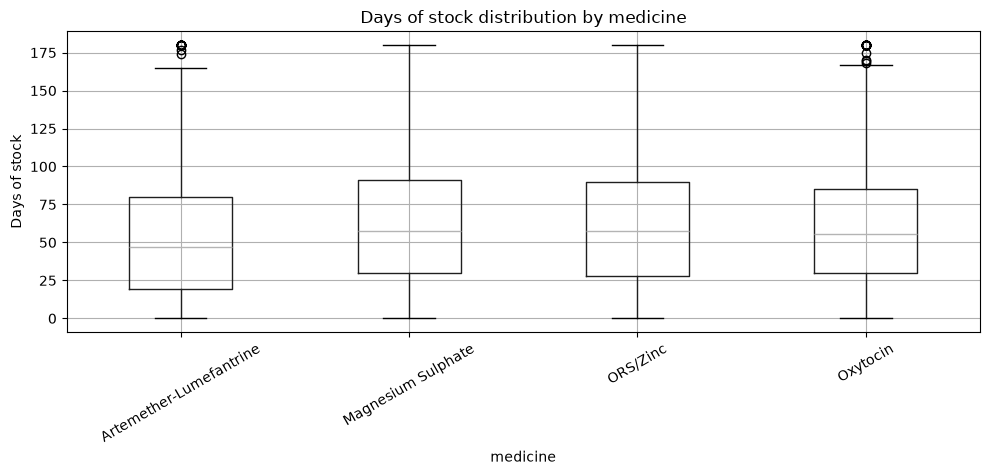

In [6]:
# Box plot to spot outliers in days_of_stock
stock.boxplot(column='days_of_stock', by='medicine', figsize=(10, 5))
plt.suptitle('')
plt.title('Days of stock distribution by medicine')
plt.ylabel('Days of stock')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4. Build the summary table

We want one row per **facility + medicine + month** with the key indicators.
This is what Superset will read to build the dashboard.

The key indicators are:
- `avg_days_of_stock` — how many days of stock remain on average
- `stockout_rate_pct` — what % of months had a stock-out
- `total_consumption` — total units consumed
- `total_stockouts` — number of stock-out months

In [7]:
summary = (
    stock
    .groupby(['facility_id', 'facility_type', 'zone', 'medicine', 'month'])
    .agg(
        avg_days_of_stock = ('days_of_stock',  'mean'),
        stockout_rate_pct = ('stockout',        lambda x: round(x.mean() * 100, 1)),
        total_consumption = ('consumption',     'sum'),
        total_stockouts   = ('stockout',        'sum'),
        stock_on_hand     = ('stock_on_hand',   'mean'),
    )
    .reset_index()
)

summary['avg_days_of_stock'] = summary['avg_days_of_stock'].round(1)

print(f'Summary table: {len(summary):,} rows')
summary.head()

Summary table: 2,149 rows


,facility_id,facility_type,zone,medicine,month,avg_days_of_stock,stockout_rate_pct,total_consumption,total_stockouts,stock_on_hand
0,ETH001,Health Centre,SNNPR,Artemether-Lumefantrine,2024-01,180.0,0.0,18,0,141.0
1,ETH001,Health Centre,SNNPR,Artemether-Lumefantrine,2024-02,180.0,0.0,18,0,123.0
2,ETH001,Health Centre,SNNPR,Artemether-Lumefantrine,2024-03,123.8,0.0,24,0,99.0
3,ETH001,Health Centre,SNNPR,Artemether-Lumefantrine,2024-04,126.3,0.0,19,0,80.0
4,ETH001,Health Centre,SNNPR,Artemether-Lumefantrine,2024-05,55.7,0.0,28,0,52.0


## 5. Add a risk flag

A simple rule: if average days of stock is below 30 days, flag the record as **at risk**.
This will be used in Superset to colour-code the dashboard.

In [8]:
summary['at_risk'] = summary['avg_days_of_stock'] < 30

print('At-risk records:', summary['at_risk'].sum())
print('Safe records:   ', (~summary['at_risk']).sum())

At-risk records: 581
Safe records:    1568


In [9]:
# What does at-risk look like broken down by medicine?
summary.groupby('medicine')['at_risk'].mean().mul(100).round(1).sort_values(ascending=False)

medicine
Artemether-Lumefantrine    34.0
ORS/Zinc                   26.2
Oxytocin                   24.0
Magnesium Sulphate         23.8
Name: at_risk, dtype: float64

## 6. Save the clean data

We save two files:
- `data/stock_clean.csv` — the cleaned raw records (used in Weeks 3 and 4)
- `data/summary.csv` — the summary table (used by Superset)

In [10]:
stock.to_csv('../data/stock_clean.csv', index=False)
summary.to_csv('../data/summary.csv', index=False)

print('Saved:')
print('  data/stock_clean.csv —', len(stock), 'rows')
print('  data/summary.csv     —', len(summary), 'rows')

Saved:
  data/stock_clean.csv — 2149 rows
  data/summary.csv     — 2149 rows


---
## ✅ Week 2 checklist

- [ ] I found how many missing values were in the data
- [ ] I filled missing values using the median per medicine
- [ ] I checked for negative or impossible values
- [ ] I built the summary table with 5 indicators
- [ ] I added the `at_risk` flag
- [ ] `data/stock_clean.csv` and `data/summary.csv` both exist

**Next step:** Open `data/summary.csv` in Superset and build your dashboard (Week 3).